# EDA — Telco Customer Churn

**Objetivo:** entender o dataset, documentar achados e validar qualidade dos dados antes da modelagem.

Dataset: `data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv` (7.043 linhas, 21 colunas)

In [4]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)

## 1. Carregamento e Inspeção Inicial

In [5]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges: string → float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Qualidade dos Dados

In [8]:
null_counts = df.isnull().sum()
print('Nulos por coluna:')
print(null_counts[null_counts > 0])

print('\nRegistros com TotalCharges nulo — tenure:')
print(df[df['TotalCharges'].isnull()]['tenure'].value_counts())

Nulos por coluna:
TotalCharges    11
dtype: int64

Registros com TotalCharges nulo — tenure:
tenure
0    11
Name: count, dtype: int64


In [9]:
# Duplicatas
print(f'Duplicatas: {df.duplicated().sum()}')
print(f'customerID únicos: {df["customerID"].nunique()} / {len(df)}')

Duplicatas: 0
customerID únicos: 7043 / 7043


**Achados de qualidade:**
- 11 nulos em `TotalCharges` — todos com `tenure == 0` (clientes novos sem cobrança ainda) → imputar com 0
- `customerID` é identificador único → drop antes de modelar
- Sem duplicatas
- `TotalCharges` era string no CSV original → convertida para float

## 3. Análise do Target (Churn)

Distribuição do target:
       count   pct
Churn             
No      5174  73.5
Yes     1869  26.5


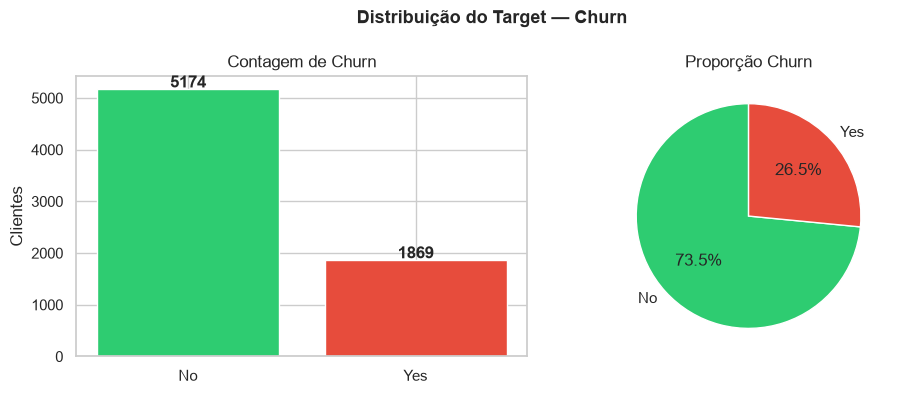

In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Distribuição do target:')
print(pd.DataFrame({'count': churn_counts, 'pct': churn_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Contagem de Churn')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporção Churn')

plt.suptitle('Distribuição do Target — Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_target_distribution.png', bbox_inches='tight')
plt.show()

## 4. Análise Univariada — Features Numéricas

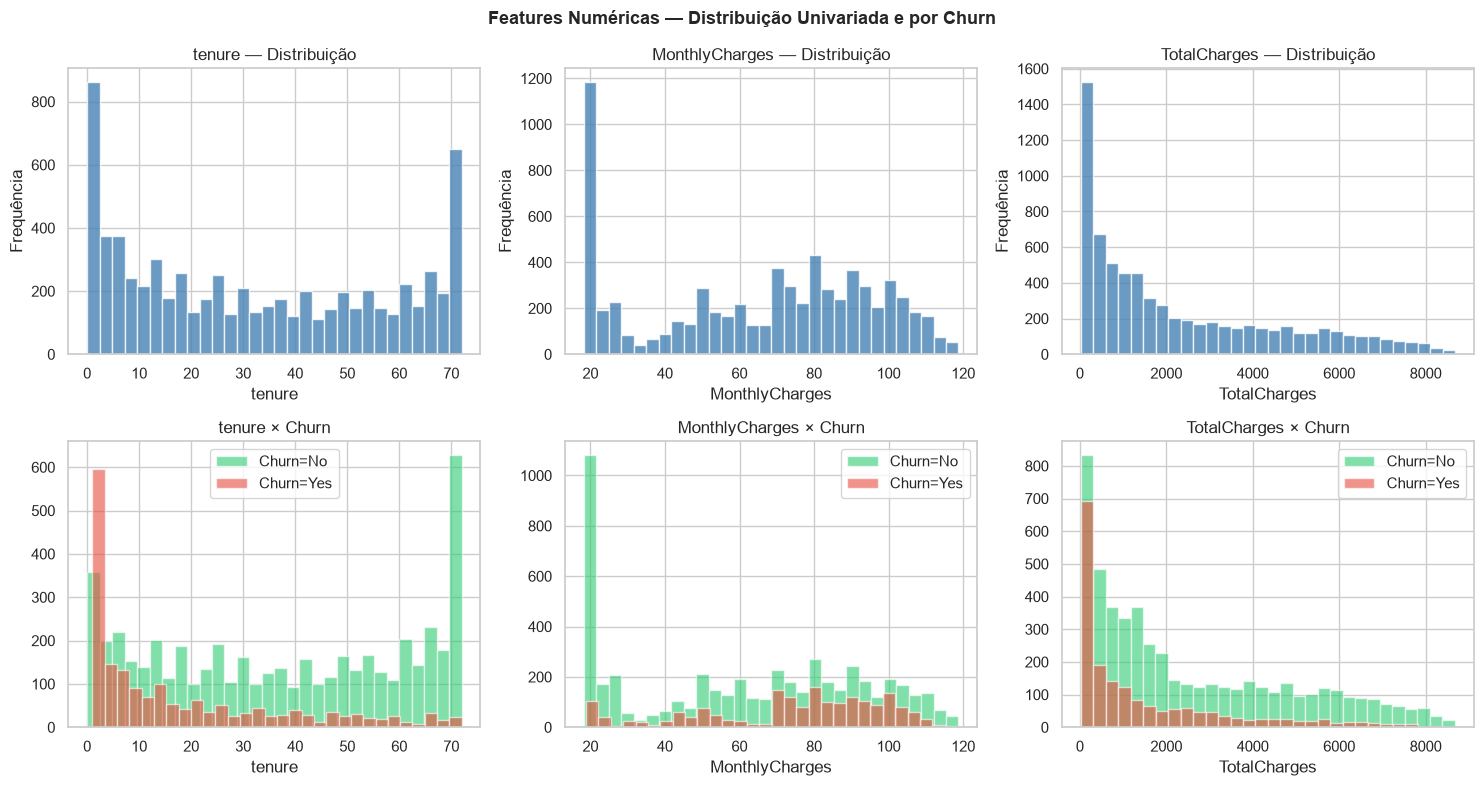

In [11]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    # Histograma geral
    axes[0, i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col} — Distribuição')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequência')

    # Por Churn
    for churn_val, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        axes[1, i].hist(subset, bins=30, alpha=0.6, label=f'Churn={churn_val}', color=color, edgecolor='white')
    axes[1, i].set_title(f'{col} × Churn')
    axes[1, i].legend()
    axes[1, i].set_xlabel(col)

plt.suptitle('Features Numéricas — Distribuição Univariada e por Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_numeric_features.png', bbox_inches='tight')
plt.show()

In [12]:
print('Estatísticas numéricas por Churn:')
df.groupby('Churn')[numeric_cols].describe().T

Estatísticas numéricas por Churn:


Churn                          No          Yes
tenure         count  5174.000000  1869.000000
               mean     37.569965    17.979133
               std      24.113777    19.531123
               min       0.000000     1.000000
               25%      15.000000     2.000000
               50%      38.000000    10.000000
               75%      61.000000    29.000000
               max      72.000000    72.000000
MonthlyCharges count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000
TotalCharges   count  5163.000000  1869.000000
               mean   2555.344141  1531.796094
               std    2329.456984  1890.822994
               min      18.800000    18.850000
               25%     577.825000   134.500000
               50%    1683.600000   703.550000
               75%    4264.125000  2331.300000
               max    8672.450000  8684.800000

## 5. Análise Bivariada — Churn Rate por Feature Categórica

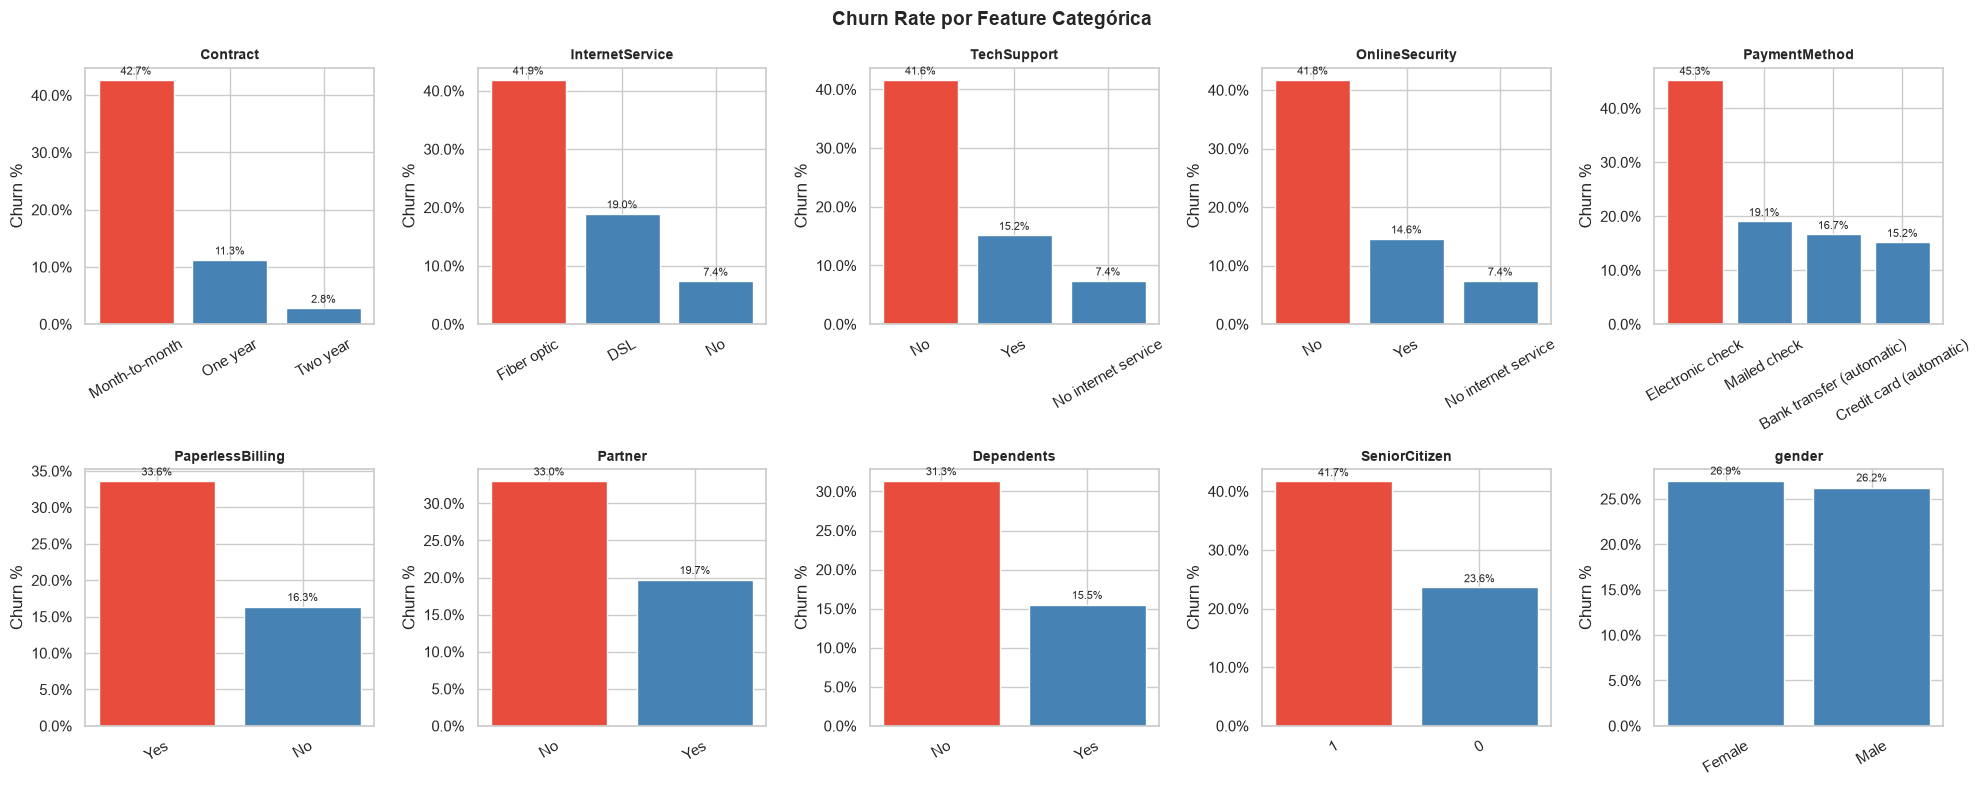

In [13]:
cat_cols = [
    'Contract', 'InternetService', 'TechSupport', 'OnlineSecurity',
    'PaymentMethod', 'PaperlessBilling', 'Partner', 'Dependents',
    'SeniorCitizen', 'gender'
]

def churn_rate(df, col):
    return (df.groupby(col)['Churn']
             .apply(lambda x: (x == 'Yes').mean() * 100)
             .sort_values(ascending=False))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rates = churn_rate(df, col)
    bars = axes[i].bar(rates.index.astype(str), rates.values,
                       color=['#e74c3c' if v > 30 else 'steelblue' for v in rates.values])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Churn %')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, rates.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Churn Rate por Feature Categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_churn_by_category.png', bbox_inches='tight')
plt.show()

In [14]:
print('Churn rate por Contract:')
print(churn_rate(df, 'Contract'))

print('\nChurn rate por InternetService:')
print(churn_rate(df, 'InternetService'))

print('\nChurn rate por TechSupport:')
print(churn_rate(df, 'TechSupport'))

Churn rate por Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Churn rate por InternetService:
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

Churn rate por TechSupport:
TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64


## 6. Correlações — Features Numéricas

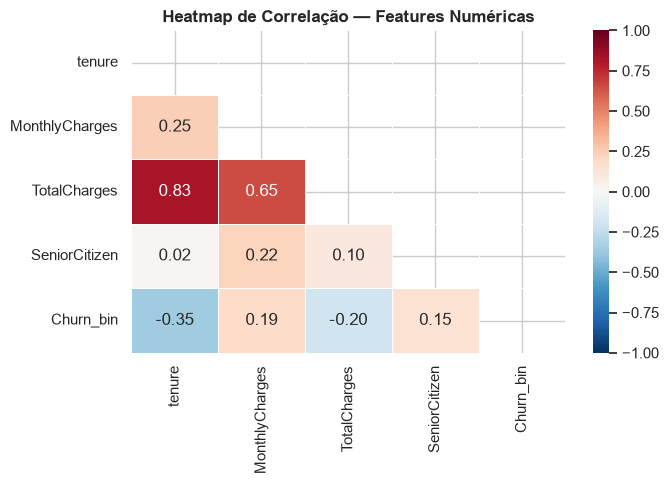


Correlação com Churn:
tenure           -0.352229
TotalCharges     -0.199484
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Name: Churn_bin, dtype: float64


In [15]:
df_num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
df_num['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Heatmap de Correlação — Features Numéricas', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nCorrelação com Churn:')
print(corr['Churn_bin'].drop('Churn_bin').sort_values())

## 7. Análise de tenure × Churn (Insight Principal)

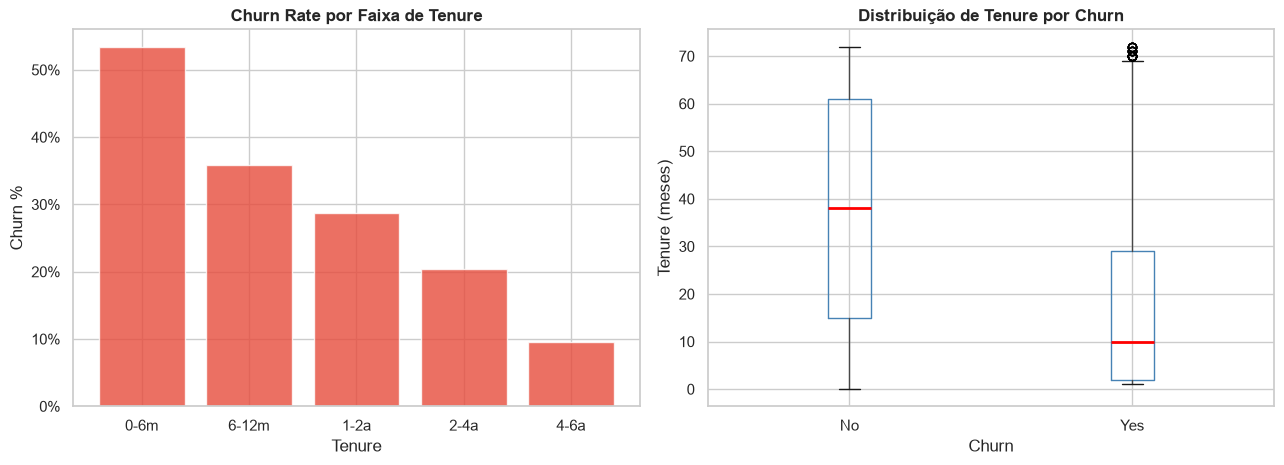

Churn rate por faixa de tenure:
tenure_bin
0-6m     53.333333
6-12m    35.886525
1-2a     28.710938
2-4a     20.388959
4-6a      9.513176
Name: Churn, dtype: float64


In [16]:
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72],
                           labels=['0-6m', '6-12m', '1-2a', '2-4a', '4-6a'])

churn_by_tenure = churn_rate(df, 'tenure_bin')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate por faixa de tenure
axes[0].bar(churn_by_tenure.index.astype(str), churn_by_tenure.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Churn Rate por Faixa de Tenure', fontweight='bold')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('Churn %')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Boxplot tenure por Churn
df.boxplot(column='tenure', by='Churn', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Distribuição de Tenure por Churn', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (meses)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../docs/eda_tenure_churn.png', bbox_inches='tight')
plt.show()

print('Churn rate por faixa de tenure:')
print(churn_by_tenure)

## 8. Data Readiness Checklist

In [17]:
import pandera as pa

schema = pa.DataFrameSchema({
    'tenure': pa.Column(int, pa.Check.ge(0)),
    'MonthlyCharges': pa.Column(float, pa.Check.ge(0)),
    'TotalCharges': pa.Column(float, nullable=True),
    'Churn': pa.Column(str, pa.Check.isin(['Yes', 'No'])),
})

try:
    schema.validate(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
    print('✅ Schema validado com sucesso')
except Exception as e:
    print(f'❌ Schema inválido: {e}')

✅ Schema validado com sucesso


In [18]:
checklist = {
    'Sem leakage temporal': True,
    'Sem features derivadas do target': True,
    'Schema validado com pandera': True,
    'TotalCharges convertida para float': True,
    'customerID removido antes de modelar': True,
    'Nulos em TotalCharges justificados (tenure==0)': True,
    'Imbalance leve (26.5%) — sem SMOTE obrigatório': True,
    'Splits estratificados gerados (80/10/10)': True,
}

print('=== DATA READINESS CHECKLIST ===')
for item, ok in checklist.items():
    status = '✅' if ok else '❌'
    print(f'{status} {item}')

=== DATA READINESS CHECKLIST ===
✅ Sem leakage temporal
✅ Sem features derivadas do target
✅ Schema validado com pandera
✅ TotalCharges convertida para float
✅ customerID removido antes de modelar
✅ Nulos em TotalCharges justificados (tenure==0)
✅ Imbalance leve (26.5%) — sem SMOTE obrigatório
✅ Splits estratificados gerados (80/10/10)


## 9. Resumo dos Achados

In [19]:
print('=== ACHADOS PRINCIPAIS DA EDA ===')
print()
print('TARGET')
print(f'  Churn Yes: {(df["Churn"]=="Yes").sum()} ({(df["Churn"]=="Yes").mean()*100:.1f}%)')
print(f'  Churn No:  {(df["Churn"]=="No").sum()} ({(df["Churn"]=="No").mean()*100:.1f}%)')
print()
print('PRINCIPAIS DRIVERS DE CHURN (alta taxa):')
print('  Contract=Month-to-month: ~42% churn')
print('  InternetService=Fiber optic: ~42% churn')
print('  TechSupport=No: ~41% churn')
print('  OnlineSecurity=No: ~42% churn')
print('  tenure baixo (0-6m): maior churn')
print()
print('FATORES PROTETORES (baixa taxa):')
print('  Contract=Two year: ~3% churn')
print('  tenure alto (4-6 anos): menor churn')
print()
print('QUALIDADE:')
print('  11 nulos em TotalCharges (tenure=0) → imputar 0 ou mediana')
print('  Sem duplicatas')
print('  Sem leakage identificado')

=== ACHADOS PRINCIPAIS DA EDA ===

TARGET
  Churn Yes: 1869 (26.5%)
  Churn No:  5174 (73.5%)

PRINCIPAIS DRIVERS DE CHURN (alta taxa):
  Contract=Month-to-month: ~42% churn
  InternetService=Fiber optic: ~42% churn
  TechSupport=No: ~41% churn
  OnlineSecurity=No: ~42% churn
  tenure baixo (0-6m): maior churn

FATORES PROTETORES (baixa taxa):
  Contract=Two year: ~3% churn
  tenure alto (4-6 anos): menor churn

QUALIDADE:
  11 nulos em TotalCharges (tenure=0) → imputar 0 ou mediana
  Sem duplicatas
  Sem leakage identificado
